<a href="https://colab.research.google.com/github/SriVidyaYeluripati/mlph_w24/blob/main/sheet05/sheet05_2%264.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sheet 5

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch

## 2 Logistic regression: an LLM lie detector

Download the data from https://heibox.uni-heidelberg.de/f/38bd3f2a9b7944248cc2/   
Unzip it and place the lie_detection folder in the folder named `data` to get the following structure:
"data/lie_detection/datasets" and "data/lie_detection/acts".

This is how you can load a dataset of LLM activations. Use a new Datamanager if you want to have a new dataset. Use the same data manager if you want to combine datasets.

In [ ]:
from lie_detection_utils import DataManager

path_to_datasets = "data/lie_detection/datasets"
path_to_acts = "data/lie_detection/acts"

# check if the datasets and activations are available
assert os.path.exists(path_to_datasets), "The path to the datasets does not exist."
assert os.path.exists(path_to_acts), "The path to the activations does not exist."

# these are the different datasets containing true and false factual statements about different topics
dataset_names = ["cities", "neg_cities", "sp_en_trans", "neg_sp_en_trans"]
dataset_name = dataset_names[0] # choose some dataset from the above datasets, index "0" loads the "cities" dataset for example

# the dataloader automatically loads the training data for us
dm = DataManager()
dm.add_dataset(dataset_name, "Llama3", "8B", "chat", layer=12, split=0.8, center=False,
                device='cpu', path_to_datasets=path_to_datasets, path_to_acts=path_to_acts)
acts_train, labels_train = dm.get('train') # train set
acts_test, labels_test = dm.get('val')
print(acts_train.shape, labels_train.shape)
print(labels_train)

torch.Size([1196, 4096]) torch.Size([1196])
tensor([0., 1., 1.,  ..., 0., 1., 0.])


In [ ]:
# have a look at the statements that were fed to the LLM to produce the activations:
df = pd.read_csv(f"{path_to_datasets}/{dataset_name}.csv")
print(df.head(10))

                                        statement  label       city  \
0             The city of Krasnodar is in Russia.      1  Krasnodar   
1       The city of Krasnodar is in South Africa.      0  Krasnodar   
2                  The city of Lodz is in Poland.      1       Lodz   
3  The city of Lodz is in the Dominican Republic.      0       Lodz   
4            The city of Maracay is in Venezuela.      1    Maracay   
5                The city of Maracay is in China.      0    Maracay   
6              The city of Baku is in Azerbaijan.      1       Baku   
7                 The city of Baku is in Ukraine.      0       Baku   
8                  The city of Baoji is in China.      1      Baoji   
9              The city of Baoji is in Guatemala.      0      Baoji   

                  country correct_country  
0                  Russia          Russia  
1            South Africa          Russia  
2                  Poland          Poland  
3  the Dominican Republic          Poland 

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

def get_datsets(ds_name, split=0.8):

    dm = DataManager()
    dm.add_dataset(ds_name, "Llama3", "8B", "chat", layer=12, split=split, center=False,
                    device='cpu', path_to_datasets=path_to_datasets, path_to_acts=path_to_acts)
    return (dm.get('train'), dm.get('val'))


def train_logistics_classifier(X_train, Y_train, regularisation=None):

    model = LogisticRegression(penalty=regularisation, solver='lbfgs', max_iter=1000, tol=1e-4)
    model.fit(X_train.numpy(), Y_train.numpy())

    return model


def evaluate_logistics_classifier(X_test, Y_test, model, model_name, test_name, silent=False):

    predictions = model.predict(X_test.numpy())
    accuracy = accuracy_score(Y_test.numpy(), predictions)

    if not silent:
        report = classification_report(Y_test.numpy(), predictions, target_names=["False", "True"])

        print(f"Classification Report: '{model_name}' Model on '{test_name}' Test Dataset:")
        print(f"Test Accuracy: {accuracy:.4f}\n")
        print(report)
        print()

    return accuracy


(cities_acts_train, cities_label_train), (cities_acts_test, cities_label_test) = get_datsets(dataset_names[0])
(neg_cities_acts_train, neg_cities_label_train), (neg_cities_acts_test, neg_cities_label_test) = get_datsets(dataset_names[1])
(sp_en_acts_train, sp_en_label_train), (sp_en_acts_test, sp_en_label_test) = get_datsets(dataset_names[2])
(neg_sp_en_acts_train, neg_sp_en_label_train), (neg_sp_en_acts_test, neg_sp_en_label_test) = get_datsets(dataset_names[3])

cities_model = train_logistics_classifier(cities_acts_train, cities_label_train)
neg_cities_model = train_logistics_classifier(neg_cities_acts_train, neg_cities_label_train)
sp_en_model = train_logistics_classifier(sp_en_acts_train, sp_en_label_train)
neg_sp_en_model = train_logistics_classifier(neg_sp_en_acts_train, neg_sp_en_label_train)

data_labels = ["Cities", "Negative Cities", "Spanish English Translation", "Negative Spanish English Translation"]

evaluate_logistics_classifier(cities_acts_test, cities_label_test, cities_model, data_labels[0], data_labels[0])
evaluate_logistics_classifier(neg_cities_acts_test, neg_cities_label_test, neg_cities_model, data_labels[1], data_labels[1])
evaluate_logistics_classifier(sp_en_acts_test, sp_en_label_test, sp_en_model, data_labels[2], data_labels[2])
evaluate_logistics_classifier(neg_sp_en_acts_test, neg_sp_en_label_test, neg_sp_en_model, data_labels[3], data_labels[3])


# Why is this important, what does it mean?
print("Evidently, the activation vectors in all of the four datasets are linearly separable. Training accuracy approaches 100% on test dataset.")

Classification Report: 'Cities' Model on 'Cities' Test Dataset:
Test Accuracy: 1.0000

              precision    recall  f1-score   support

       False       1.00      1.00      1.00       159
        True       1.00      1.00      1.00       141

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300


Classification Report: 'Negative Cities' Model on 'Negative Cities' Test Dataset:
Test Accuracy: 1.0000

              precision    recall  f1-score   support

       False       1.00      1.00      1.00       142
        True       1.00      1.00      1.00       158

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300


Classification Report: 'Spanish English Translation' Model on 'Spanish English Translation' Test Dataset:
Test Accuracy: 1.0000

              precision

Out of distribution generalisation.

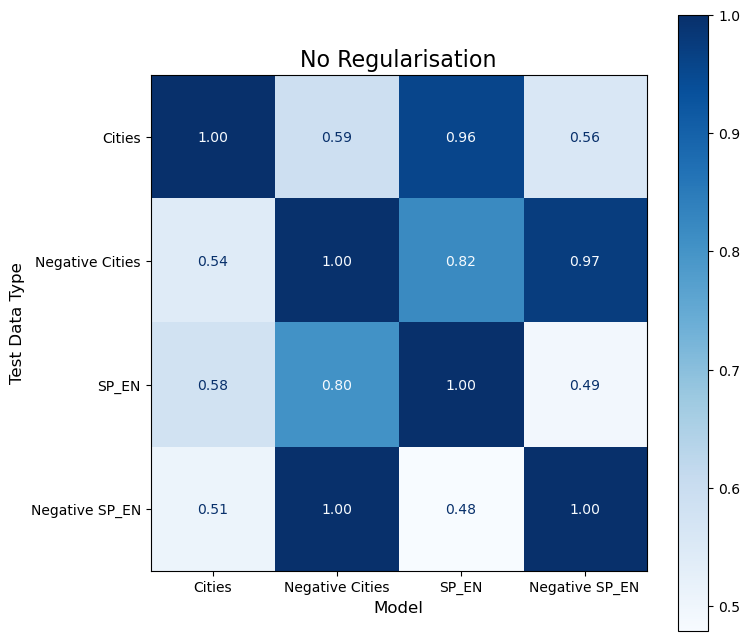

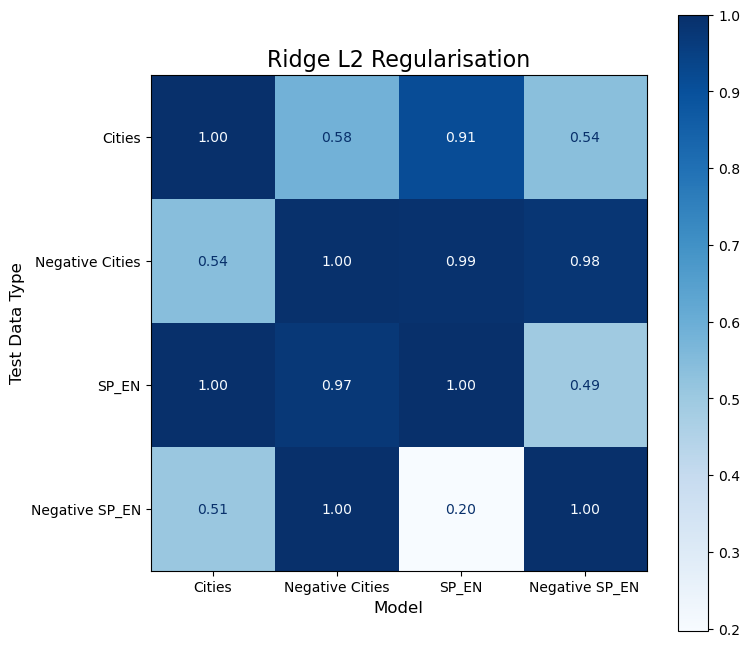

All models achieve 100% accuracy on the test data associated with them (see diagonal).
Evidently models trained on identifying normal statements, struggle to identify negated statements.
The Negative cities model performed very well on negative Spanish English Translation Data, demonstrating successful generalisation.
The same is true for the Negative Spanish English translation model, which performed very well on the Negative Cities Test Data.
While the Spanish English Translation model achieved high accuracy on the cities data, the converse is not true (assymetry).
With Ridge regularisation this assymetry is removed. Additionally, all models perform better on the other three datasets, demonstrating the benefits regularisation has on generalisation of the model.


In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

train_Xs = [cities_acts_train, neg_cities_acts_train, sp_en_acts_train, neg_sp_en_acts_train]
train_Ys = [cities_label_train, neg_cities_label_train, sp_en_label_train, neg_sp_en_label_train]

test_Xs = [cities_acts_test, neg_cities_acts_test, sp_en_acts_test, neg_sp_en_acts_test]
test_Ys = [cities_label_test, neg_cities_label_test, sp_en_label_test, neg_sp_en_label_test]

models = [ cities_model, neg_cities_model, sp_en_model, neg_sp_en_model]
ridge_models = [ train_logistics_classifier(train_X, train_Y, regularisation="l2") for train_X, train_Y in zip(train_Xs, train_Ys) ]


def calculate_generalisation_accuracy_matrix(models, test_Xs, test_Ys):
    m_count = len(models)
    accuracy_matrix = np.zeros((m_count, m_count))

    for im, model in enumerate(models):
        for ixy, (test_X, test_Y) in enumerate(zip(test_Xs, test_Ys)):
            accuracy_matrix[im, ixy] = evaluate_logistics_classifier(test_X, test_Y, model, None, None, silent=True)

    return accuracy_matrix

def display_confusion_matrix(confusion_matrix, x_labels, y_labels, title, x_label="Model", y_label="Test Data Type"):

    fig, ax = plt.subplots(figsize=(8, 8))
    disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix.T)

    disp.plot(cmap="Blues", ax=ax, values_format='.2f')

    ax.set_xticks(np.arange(len(x_labels)))
    ax.set_xticklabels(x_labels, fontsize=10)
    ax.set_yticks(np.arange(len(y_labels)))
    ax.set_yticklabels(y_labels, fontsize=10)

    ax.set_title(title, fontsize=16)
    ax.set_xlabel(x_label, fontsize=12)
    ax.set_ylabel(y_label, fontsize=12)

    plt.show()


acc_matrix = calculate_generalisation_accuracy_matrix(models, test_Xs, test_Ys)
ridge_acc_matrix = calculate_generalisation_accuracy_matrix(ridge_models, test_Xs, test_Ys)

data_labels = ["Cities", "Negative Cities", "SP_EN", "Negative SP_EN"]

display_confusion_matrix(acc_matrix, data_labels, data_labels, "No Regularisation")
display_confusion_matrix(ridge_acc_matrix, data_labels, data_labels, "Ridge L2 Regularisation")

print("All models achieve 100% accuracy on the test data associated with them (see diagonal).")
print("Evidently models trained on identifying normal statements, struggle to identify negated statements.")
print("The Negative cities model performed very well on negative Spanish English Translation Data, demonstrating successful generalisation.")
print("The same is true for the Negative Spanish English translation model, which performed very well on the Negative Cities Test Data.")
print("While the Spanish English Translation model achieved high accuracy on the cities data, the converse is not true (assymetry).")
print("With Ridge regularisation this assymetry is removed. Additionally, all models perform better on the other three datasets, demonstrating the benefits regularisation has on generalisation of the model.")

Classification Report: 'Mixed Cities' Model on 'Mixed Cities' Test Dataset:
Test Accuracy: 0.9983

              precision    recall  f1-score   support

       False       1.00      1.00      1.00       294
        True       1.00      1.00      1.00       306

    accuracy                           1.00       600
   macro avg       1.00      1.00      1.00       600
weighted avg       1.00      1.00      1.00       600




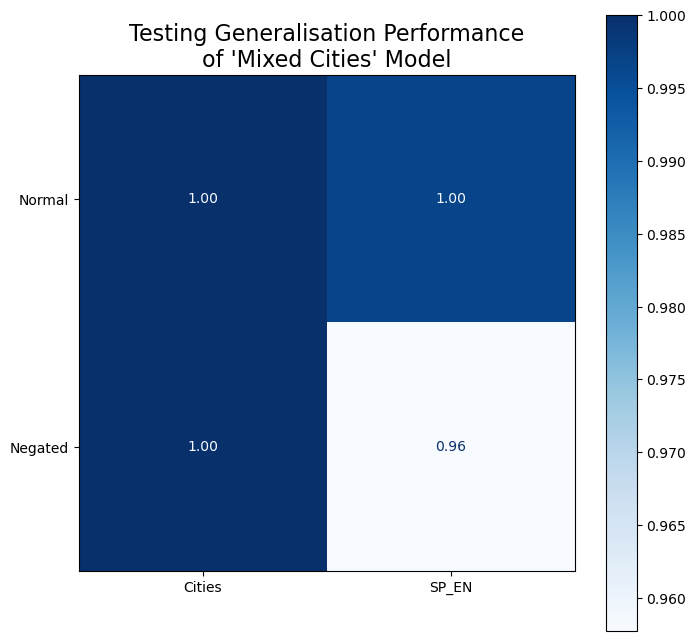

Evidently if the model is trained on both normal and negated data, it can generalise this capability from cities to Spanish English Translation.


In [ ]:
pos_neg_cities_acts_train = np.concatenate((cities_acts_train, neg_cities_acts_train))
pos_neg_cities_label_train = np.concatenate((cities_label_train, neg_cities_label_train))
pos_neg_cities_acts_test = np.concatenate((cities_acts_test, neg_cities_acts_test))
pos_neg_cities_label_test = np.concatenate((cities_label_test, neg_cities_label_test))

def shuffle_data(X, Y):

    permutation = np.random.permutation(Y.shape[0])
    shuffled_X = X[permutation, :]
    shuffled_Y = Y[permutation]

    return torch.tensor(shuffled_X), torch.tensor(shuffled_Y)

np.random.seed(0)


pos_neg_cities_acts_train, pos_neg_cities_labels_train = shuffle_data(pos_neg_cities_acts_train, pos_neg_cities_label_train)
pos_neg_cities_acts_test, pos_neg_cities_labels_test = shuffle_data(pos_neg_cities_acts_test, pos_neg_cities_label_test)

pos_neg_cities_model = train_logistics_classifier(pos_neg_cities_acts_train, pos_neg_cities_labels_train)

evaluate_logistics_classifier(pos_neg_cities_acts_test, pos_neg_cities_labels_test, pos_neg_cities_model, "Mixed Cities", "Mixed Cities")

# Create matrix to visualise performance on all sub-datasets.
generalisation_matrix = np.zeros((2, 2))

generalisation_matrix[0, 0] = evaluate_logistics_classifier(cities_acts_test, cities_label_test, pos_neg_cities_model, None, None, silent=True)
generalisation_matrix[1, 0] = evaluate_logistics_classifier(neg_cities_acts_test, neg_cities_label_test, pos_neg_cities_model, None, None, silent=True)
generalisation_matrix[0, 1] = evaluate_logistics_classifier(sp_en_acts_test, sp_en_label_test, pos_neg_cities_model, None, None, silent=True)
generalisation_matrix[1, 1] = evaluate_logistics_classifier(neg_sp_en_acts_test, neg_sp_en_label_test, pos_neg_cities_model, None, None, silent=True)

x_labels = ["Cities", "SP_EN"]
y_labels = ["Normal", "Negated"]

display_confusion_matrix(generalisation_matrix, x_labels, y_labels, "Testing Generalisation Performance\nof 'Mixed Cities' Model", x_label="", y_label="")

print("Evidently if the model is trained on both normal and negated data, it can generalise this capability from cities to Spanish English Translation.")

## 3 Log-sum-exp and soft(arg)max
### (b)

### (c)

## 4 Linear regions of MLPs

#### Part (a): Implementing a Shallow Neural Network
In this part, we implemented a **shallow neural network** with **one hidden layer** containing **20 neurons**.


1. **Input Layer**:
   - Let the input be a **2-dimensional vector** $ \mathbf{x} = [x_1, x_2]^T $.

2. **Hidden Layer**:
   - The hidden layer takes the input and performs a **linear transformation**, followed by a **ReLU activation function**.
   - Let $ \mathbf{W_1} $ be the **weight matrix** of size $ 20 \times 2 $, and let $ \mathbf{b_1} $ be the **bias vector** of size $ 20 \times 1 $.
   - The **output of the hidden layer** $ \mathbf{h_1} $ is computed as:

   $$
   \mathbf{h_1} = \text{ReLU}(\mathbf{W_1} \mathbf{x} + \mathbf{b_1})
   $$

   where **ReLU** is the activation function defined as:

   $$
   \text{ReLU}(z) = \max(0, z)
   $$

3. **Output Layer**:
   - The output layer takes the **20 hidden units** and computes the **final output**.
   - Let $ \mathbf{W_2} $ be the **weight vector** of size $ 1 \times 20 $, and let $ b_2 $ be the **bias term** (scalar).
   - The final output $ y $ is computed as:

   $$
   y = \mathbf{W_2} \mathbf{h_1} + b_2
   $$

4. **Total Number of Parameters**:
   - Hidden Layer: $ 2 \text{ inputs } \times 20 \text{ neurons } + 20 \text{ biases } = 60 $ parameters.
   - Output Layer: $ 20 \text{ inputs } \times 1 \text{ output } + 1 \text{ bias } = 21 $ parameters.
   - **Total Parameters**: $ 60 + 21 = 81 $

In [ ]:
import torch
import torch.nn as nn

torch.manual_seed(42)

class ShallowModel(nn.Module):
    def __init__(self):
        nn.Module.__init__(self)  # Initialize the base neural network class

        # Hidden layer takes 2 inputs and sends to 20 neurons
        self.hidden_layer = nn.Linear(2, 20)  # Parameters: 2 inputs * 20 neurons + 20 biases = 40 weights + 20 biases = 60 parameters total

        # Output layer takes 20 inputs and sends to 1 output neuron
        self.output_layer = nn.Linear(20, 1)  # Parameters: 20 inputs * 1 output + 1 bias = 20 weights + 1 bias = 21 parameters total

    def forward(self, x):
        # Pass the input through the hidden layer and apply ReLU to keep only positive values
        x = torch.relu(self.hidden_layer(x))

        # Pass the result through the output layer to get the final value
        x = self.output_layer(x)

        return x

shallow_model = ShallowModel()
num_params = 0
for param in shallow_model.parameters():
    # If the parameter can be learned (i.e., updated during training)
    if param.requires_grad:

        num_params += param.numel()
print("The number of parameters in the model is:", num_params)  # Output: The number of parameters in the model is: 81


The number of parameters in the model is: 81


#### Part (b): Evaluating the Model on a Grid
In this part, we evaluated the output of the shallow model on a **2D grid** of values ranging from $ -10 $ to $ 10 $ for both $x$ and $y$.


1. **Grid Creation**:
   - The **input space** was defined by two vectors: $ x \in [-10, 10] $ and $ y \in [-10, 10] $.
   - We created a **meshgrid** of these values, generating **500 points** in each direction, resulting in $500 \times 500 = 250,000$ points.

2. **Passing the Grid Through the Model**:
   - Let $ \mathbf{X} $ be the matrix containing all points on the grid, with shape $ 250000 \times 2 $.
   - The output of the model $ Y $ for each point is calculated as:

   $$
   Y = f(\mathbf{X})
   $$

   where $ f $ represents the **forward pass** through the shallow model.
   - The output values were then reshaped into a **500x500** matrix to match the original grid structure.

3. **Visualization**:
   - The **output values** were plotted on the 2D grid to visualize how the model maps the inputs to the output.

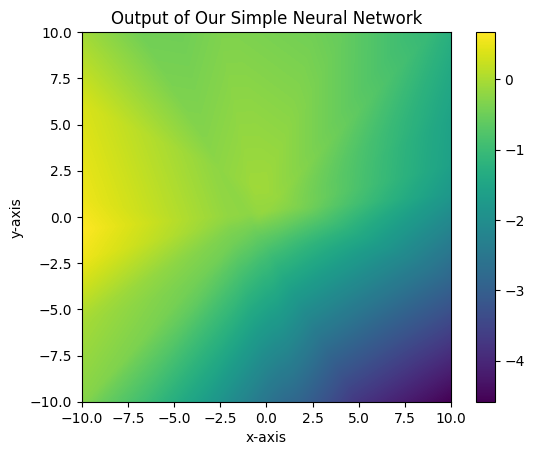

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch


# Define the range of values for x and y, from -10 to 10 with 500 points each
x_values = np.linspace(-10, 10, 500)
y_values = np.linspace(-10, 10, 500)

# Could use np.meshgrid() to make the grid points , but coded to better  understanding of what really happens
xx = []  # List to hold all x coordinates of the grid
yy = []  # List to hold all y coordinates of the grid
for y in y_values:
    for x in x_values:
        xx.append(x)
        yy.append(y)

grid_points = []
for i in range(len(xx)):
    grid_points.append([xx[i], yy[i]])

grid_points = np.array(grid_points)  # Shape  (250000, 2)

grid_tensor = torch.tensor(grid_points, dtype=torch.float32)  # Convert to a tensor for PyTorch

# We do not need to calculate gradients, hence the no_grad context manager
with torch.no_grad():
    output_tensor = shallow_model(grid_tensor)  # Pass the grid through the shallow model
    output_values = output_tensor.numpy()  # Convert the output tensor to NumPy array

output_values = output_values.reshape((500, 500))  # Reshape to match the grid of x and y  (500 x 500)

plt.imshow(output_values, extent=(-10, 10, -10, 10), origin='lower', cmap='viridis')
plt.colorbar()  # Add color bar to show the value range
plt.title("Output of Our Simple Neural Network")
plt.xlabel("x-axis")
plt.ylabel("y-axis")
plt.show()  # Display the plot


#### Part (c): Computing and Visualizing Gradients
In this part, we computed the **spatial gradients** of the model's output over the 2D input space using `numpy.gradient()`.


1. **Gradients of the Output**:
   - Given the output $ Y = f(\mathbf{X}) $, we want to calculate the **partial derivatives** with respect to each input dimension $ x $ and $ y $.
   - The **gradient** is a vector that indicates the **rate of change** of the output with respect to changes in the input.
   - Let $ \frac{\partial Y}{\partial x} $ be the partial derivative of $ Y $ with respect to $ x $, and let $ \frac{\partial Y}{\partial y} $ be the partial derivative with respect to $ y $.

2. **Using `numpy.gradient()`**:
   - We approximated the gradients numerically using `numpy.gradient()`:

   $$
   \text{gradient_x}, \text{gradient_y} = \nabla Y = \left( \frac{\partial Y}{\partial x}, \frac{\partial Y}{\partial y} \right)
   $$

   - The gradients provide information about how the model output changes when we move along the $x$ or $y$ directions in the input space.

3. **Visualization**:
   - **Gradient Visualization** helps us understand how the model’s output changes at each point on the grid.
   - The **color variations** in the gradient plots indicate regions of higher or lower sensitivity of the model's output to changes in the input values.

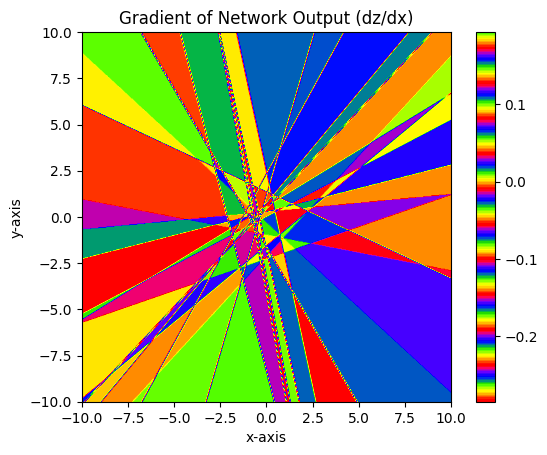

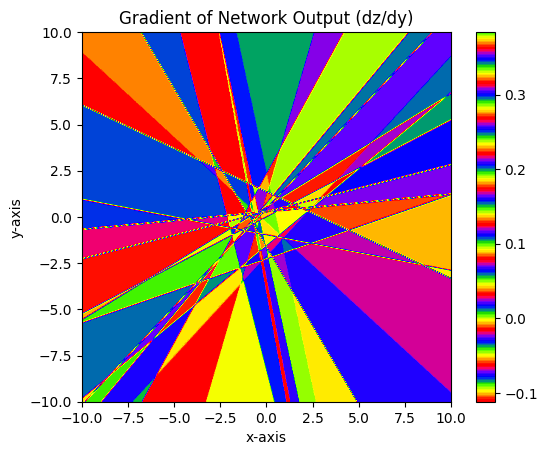

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


gradient_y, gradient_x = np.gradient(output_values, y_values, x_values)

plt.imshow(gradient_x, extent=(-10, 10, -10, 10), origin='lower', cmap='prism')
plt.colorbar()
plt.title("Gradient of Network Output (dz/dx)")
plt.xlabel("x-axis")
plt.ylabel("y-axis")
plt.show()

plt.imshow(gradient_y, extent=(-10, 10, -10, 10), origin='lower', cmap='prism')
plt.colorbar()
plt.title("Gradient of Network Output (dz/dy)")
plt.xlabel("x-axis")
plt.ylabel("y-axis")
plt.show()


#### Part (d): Implementing a Deep Neural Network
In this part, we implemented a **deeper model** with **four hidden layers**, each containing **5 neurons**.

**Mathematical Explanation**:

1. **Deep Model Architecture**:
   - The deep model has **four hidden layers**, each with **5 neurons**, and **ReLU activation** applied at each layer.
   - **Input Layer**: Let the input be $ \mathbf{x} = [x_1, x_2]^T $.
   - **Hidden Layers**:
     - **Layer 1**:
       $$
       \mathbf{h_1} = \text{ReLU}(\mathbf{W_1} \mathbf{x} + \mathbf{b_1})
       $$
       where $ \mathbf{W_1} $ is of size $ 5 \times 2 $, and $ \mathbf{b_1} $ is of size $ 5 \times 1 $.
     - **Layer 2**:
       $$
       \mathbf{h_2} = \text{ReLU}(\mathbf{W_2} \mathbf{h_1} + \mathbf{b_2})
       $$
       where $ \mathbf{W_2} $ is of size $ 5 \times 5 $.
     - **Layer 3**:
       $$
       \mathbf{h_3} = \text{ReLU}(\mathbf{W_3} \mathbf{h_2} + \mathbf{b_3})
       $$
       where $ \mathbf{W_3} $ is of size $ 5 \times 5 $.
     - **Layer 4**:
       $$
       \mathbf{h_4} = \text{ReLU}(\mathbf{W_4} \mathbf{h_3} + \mathbf{b_4})
       $$
       where $ \mathbf{W_4} $ is of size $ 5 \times 5 $.
   - **Output Layer**: The final output is computed as:

   $$
   y = \mathbf{W_5} \mathbf{h_4} + b_5
   $$

   where $ \mathbf{W_5} $ is of size $ 1 \times 5 $, and $ b_5 $ is a scalar bias term.

2. **Total Number of Parameters**:
   - **Hidden Layers**:
     - **Layer 1**: $ 2 \times 5 + 5 = 15 $ parameters.
     - **Layer 2, 3, and 4**: Each has $ 5 \times 5 + 5 = 30 $ parameters.
   - **Output Layer**: $ 5 \times 1 + 1 = 6 $ parameters.
   - **Total Parameters**: $ 15 + 30 \times 3 + 6 = 111 $


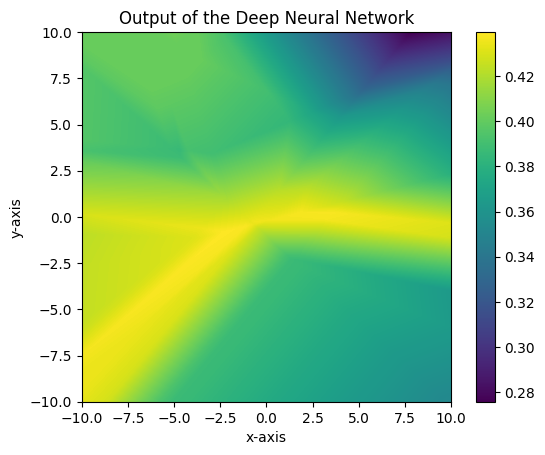

In [ ]:
import torch
import torch.nn as nn


torch.manual_seed(42)

class DeepModel(nn.Module):
    def __init__(self):
        nn.Module.__init__(self)

        # define four hidden layers with 5 neurons each
        self.hidden_layer1 = nn.Linear(2, 5)  # Input size of 2, output size of 5
        self.hidden_layer2 = nn.Linear(5, 5)  # Input and output size both 5
        self.hidden_layer3 = nn.Linear(5, 5)  # Input and output size both 5
        self.hidden_layer4 = nn.Linear(5, 5)  # Input and output size both 5

        # Define the output layer that takes the 5 neurons from the last hidden layer and gives 1 output
        self.output_layer = nn.Linear(5, 1)

    def forward(self, x):
        # Pass through each hidden layer, applying ReLU activation after each
        x = torch.relu(self.hidden_layer1(x))
        x = torch.relu(self.hidden_layer2(x))
        x = torch.relu(self.hidden_layer3(x))
        x = torch.relu(self.hidden_layer4(x))

        # Finally pass through the output layer without activation
        x = self.output_layer(x)
        return x

deep_model = DeepModel()


with torch.no_grad():
    output_values_deep = deep_model(grid_tensor).numpy()  # Predict values using the deep model


output_values_deep = output_values_deep.reshape((500, 500))

plt.imshow(output_values_deep, extent=(-10, 10, -10, 10), origin='lower', cmap='viridis')
plt.colorbar()
plt.title("Output of the Deep Neural Network")
plt.xlabel("x-axis")
plt.ylabel("y-axis")
plt.show()


####Comparing Two models

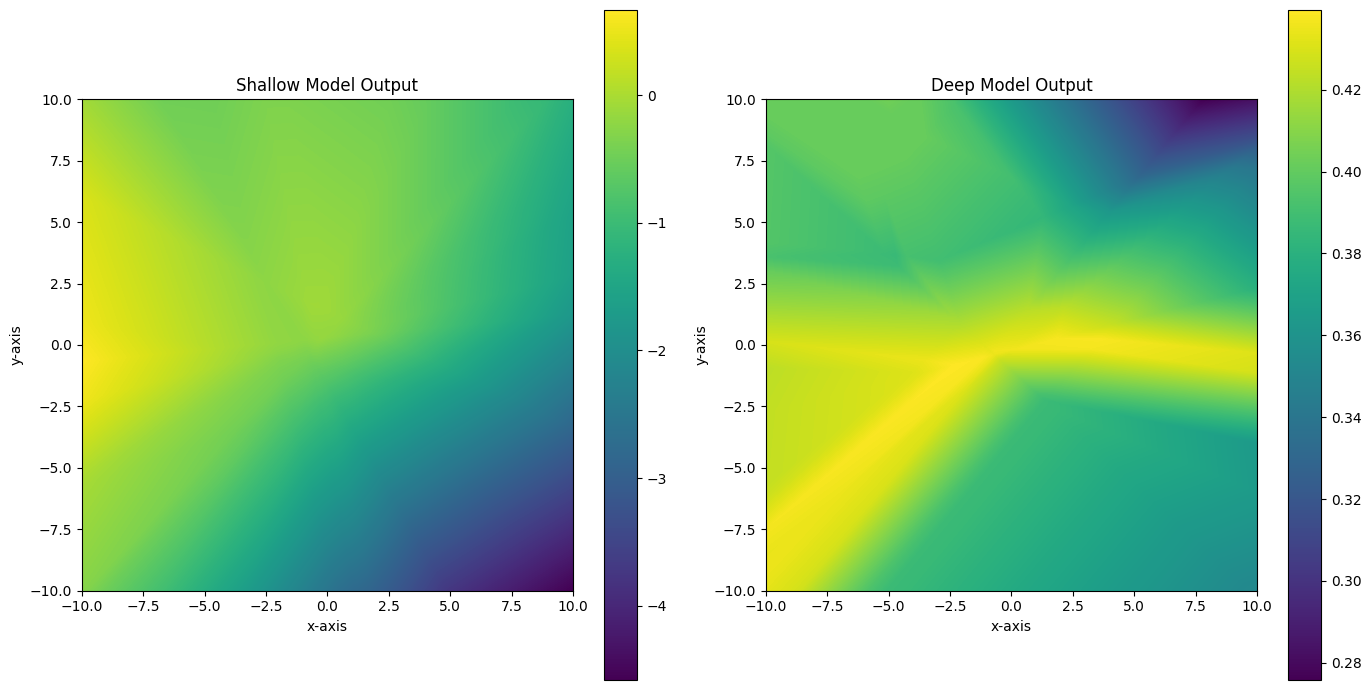

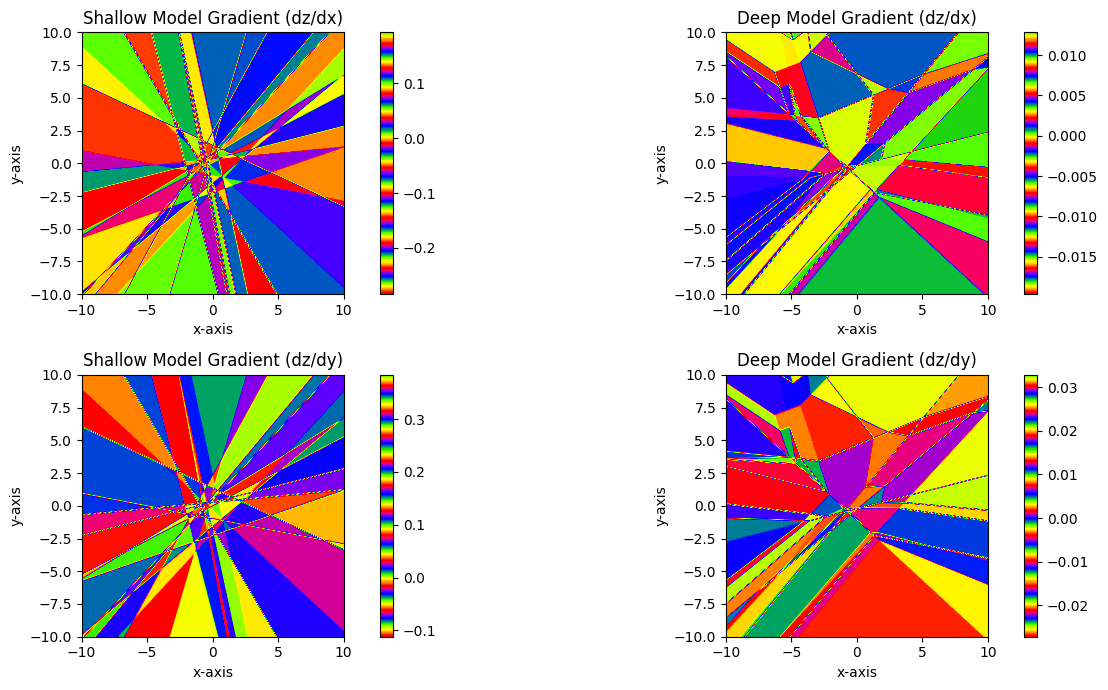

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt


torch.manual_seed(42)
shallow_model = ShallowModel()

torch.manual_seed(42)
deep_model = DeepModel()

grid_tensor = torch.tensor(grid_points, dtype=torch.float32)

# S Generate Outputs for Both Models (Shallow and Deep)
with torch.no_grad():
    # Generate output for shallow model
    output_values_shallow = shallow_model(grid_tensor).numpy().reshape(500, 500)

    # Generate output for deep model
    output_values_deep = deep_model(grid_tensor).numpy().reshape(500, 500)


plt.figure(figsize=(14, 7))

# Shallow Model Output
plt.subplot(1, 2, 1)
plt.imshow(output_values_shallow, extent=(-10, 10, -10, 10), origin='lower', cmap='viridis')
plt.colorbar()
plt.title("Shallow Model Output")
plt.xlabel("x-axis")
plt.ylabel("y-axis")

# Deep Model Output
plt.subplot(1, 2, 2)
plt.imshow(output_values_deep, extent=(-10, 10, -10, 10), origin='lower', cmap='viridis')
plt.colorbar()
plt.title("Deep Model Output")
plt.xlabel("x-axis")
plt.ylabel("y-axis")

plt.tight_layout()
plt.show()

# Calculate gradients using np.gradient
gradient_y_shallow, gradient_x_shallow = np.gradient(output_values_shallow, y_values, x_values)
gradient_y_deep, gradient_x_deep = np.gradient(output_values_deep, y_values, x_values)


plt.figure(figsize=(14, 7))

# Shallow Model Gradient (dz/dx)
plt.subplot(2, 2, 1)
plt.imshow(gradient_x_shallow, extent=(-10, 10, -10, 10), origin='lower', cmap='prism')
plt.colorbar()
plt.title("Shallow Model Gradient (dz/dx)")
plt.xlabel("x-axis")
plt.ylabel("y-axis")

# Deep Model Gradient (dz/dx)
plt.subplot(2, 2, 2)
plt.imshow(gradient_x_deep, extent=(-10, 10, -10, 10), origin='lower', cmap='prism')
plt.colorbar()
plt.title("Deep Model Gradient (dz/dx)")
plt.xlabel("x-axis")
plt.ylabel("y-axis")

# Shallow Model Gradient (dz/dy)
plt.subplot(2, 2, 3)
plt.imshow(gradient_y_shallow, extent=(-10, 10, -10, 10), origin='lower', cmap='prism')
plt.colorbar()
plt.title("Shallow Model Gradient (dz/dy)")
plt.xlabel("x-axis")
plt.ylabel("y-axis")

# Deep Model Gradient (dz/dy)
plt.subplot(2, 2, 4)
plt.imshow(gradient_y_deep, extent=(-10, 10, -10, 10), origin='lower', cmap='prism')
plt.colorbar()
plt.title("Deep Model Gradient (dz/dy)")
plt.xlabel("x-axis")
plt.ylabel("y-axis")

plt.tight_layout()
plt.show()


#### **Observations**:

##### **Shallow Model**:


  $$
  y = \mathbf{W_2} \cdot \text{ReLU}(\mathbf{W_1} \mathbf{x} + \mathbf{b_1}) + b_2
  $$

- **Total Parameters**:
  - **Hidden Layer**: \( 2 \times 20 + 20 = 60 \) parameters.
  - **Output Layer**: \( 20 \times 1 + 1 = 21 \) parameters.
  - **Total**: \( 60 + 21 = 81 \)

- **Interpretation**:
  - The **shallow model** captures simple, low-level patterns, making it suitable for tasks with straightforward relationships. It generalizes well but lacks the capacity to learn complex, non-linear interactions.

###### **Deep Model**:


  $$
  y = \mathbf{W_5} \cdot \text{ReLU}(\mathbf{W_4} \cdot \text{ReLU}(\mathbf{W_3} \cdot \text{ReLU}(\mathbf{W_2} \cdot \text{ReLU}(\mathbf{W_1} \mathbf{x} + \mathbf{b_1}) + \mathbf{b_2}) + \mathbf{b_3}) + \mathbf{b_4}) + b_5
  $$

- **Total Parameters**:
  - **Layer 1**: \( 2 \times 5 + 5 = 15 \) parameters.
  - **Layers 2, 3, 4**: Each has \( 5 \times 5 + 5 = 30 \) parameters, totaling \( 30 \times 3 = 90 \).
  - **Output Layer**: \( 5 \times 1 + 1 = 6 \) parameters.
  - **Total**: \( 15 + 90 + 6 = 111 \)

- **Interpretation**:
  - The **deep model** has more layers and parameters, allowing it to learn intricate, non-linear relationships. This makes it suitable for complex tasks but increases training time and the risk of overfitting without proper regularization.

#### **Key Takeaways**:

- **Shallow Model (81 Parameters)**: Captures simple patterns and is effective for linear or mildly non-linear tasks. It is faster to train and generalizes well for simpler data.
  
- **Deep Model (111 Parameters)**: Learns complex, non-linear relationships thanks to more parameters and deeper layers. Better for intricate tasks, but requires careful training to avoid overfitting.
